Computing Dynamic Correlation - CLIP-HBA-Dynamic: 100%|██████████| 71/71 [00:00<00:00, 1521.48it/s]


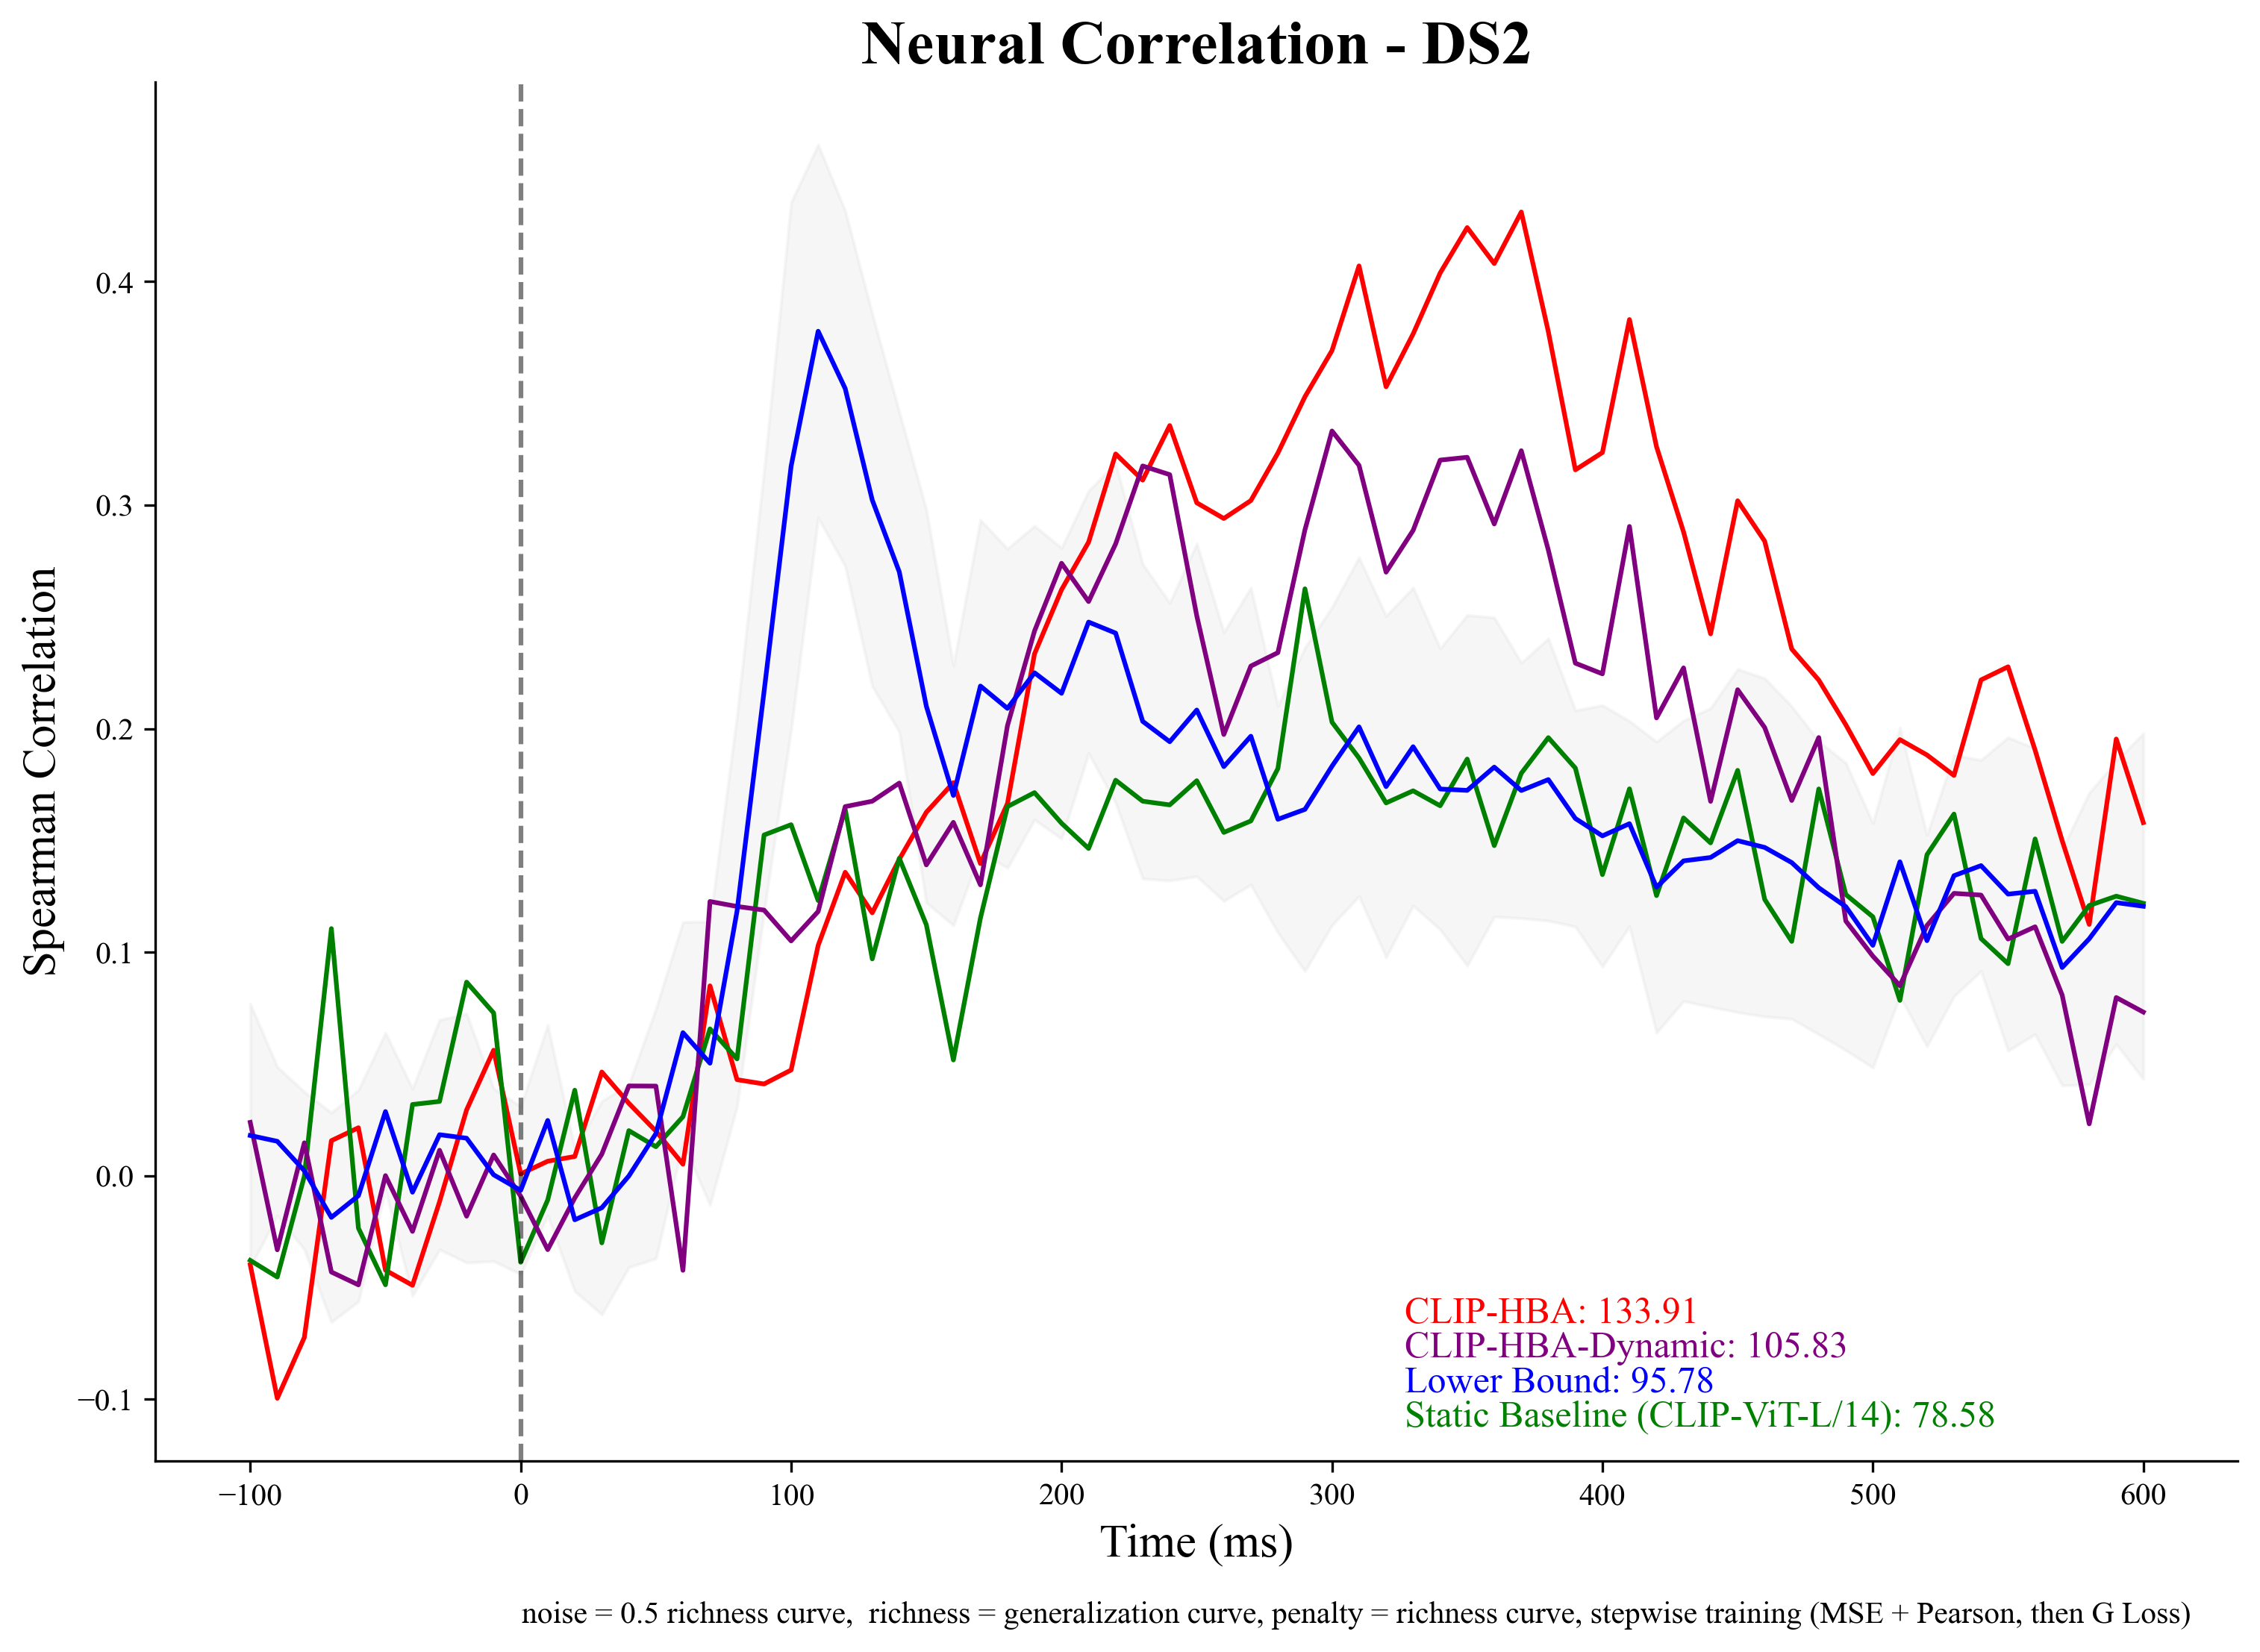

In [21]:
import os
import h5py
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
from multiprocessing import Pool
from tqdm import tqdm
from numpy import trapz
from scipy.io import loadmat
from scipy.special import softmax
from tqdm import tqdm
import pandas as pd
plt.rcParams['font.family'] = 'Times New Roman'  # Set font to Times New Roman

def load_dynamic_rdms(dynamic_rdm_dir):
    rdms = np.load(dynamic_rdm_dir)
    return rdms

def process_neural_rdms(path, neural_ms_start=-100, neural_ms_end=600, neural_ms_step=10):
    if path.endswith('.mat'):
        try:
            mat = loadmat(path)['result_dsm']
            neural_rdms = np.transpose(mat, (0, 3, 1, 2))
        except NotImplementedError:
            with h5py.File(path, 'r') as f:
                mat = f['result_dsm'][:]
                neural_rdms = np.transpose(mat, (3, 0, 1, 2))
    elif path.endswith('.npy'):
        neural_rdms = np.load(path)
        
    average_neural_rdms = np.mean(neural_rdms, axis=0)

    return neural_rdms, average_neural_rdms

def find_neural_index(ms_timepoint):
    return neural_timepoints_list.index(ms_timepoint)

def ms_to_model_index(ms_timepoint, ms_start, ms_step):
    return (ms_timepoint - ms_start) // ms_step

def calculate_model_correlation(model_rdm, neural_rdms, model_desc = "CLIP-HBA"):
    model_correlations = []
    indices = np.triu_indices_from(model_rdm, k=1)
    model_rdm_flat = model_rdm[indices]
    for time_point in tqdm(range(neural_rdms.shape[0]), desc=f"Computing Static Correlation - {model_desc}"):
        neural_rdm_flat = neural_rdms[time_point][indices]
        corr, _ = spearmanr(model_rdm_flat, neural_rdm_flat)
        model_correlations.append(corr)
    return model_correlations


def compute_dynamic_model_correlation(model_rdms, neural_rdms, model_desc = "CLIP-HBA-Dynamic"):
    assert model_rdms.shape[1:] == neural_rdms.shape[1:], "Model and neural RDMs must have the same shape"
    dynamic_correlations = []
    for neural_timepoint in tqdm(neural_timepoints_list, desc = f"Computing Dynamic Correlation - {model_desc}"):
        neural_rdm_index = find_neural_index(neural_timepoint)
        neural_rdm = neural_rdms[neural_rdm_index]
        if neural_timepoint <= model_ms_start:
            model_rdm = model_rdms[0]
            model_rdm_flat = model_rdm[np.triu_indices_from(model_rdm, k=1)]
            neural_rdm_flat = neural_rdm[np.triu_indices_from(neural_rdm, k=1)]
            corr, _ = spearmanr(model_rdm_flat, neural_rdm_flat)
            dynamic_correlations.append(corr)
        elif neural_timepoint >= model_ms_end:
            model_rdm = model_rdms[-1]
            model_rdm_flat = model_rdm[np.triu_indices_from(model_rdm, k=1)]
            neural_rdm_flat = neural_rdm[np.triu_indices_from(neural_rdm, k=1)]
            corr, _ = spearmanr(model_rdm_flat, neural_rdm_flat)
            dynamic_correlations.append(corr)
        else:    
            model_rdm = model_rdms[ms_to_model_index(neural_timepoint, model_ms_start, model_ms_step)]
            model_rdm_flat = model_rdm[np.triu_indices_from(model_rdm, k=1)]
            neural_rdm_flat = neural_rdm[np.triu_indices_from(neural_rdm, k=1)]
            corr, _ = spearmanr(model_rdm_flat, neural_rdm_flat)
            dynamic_correlations.append(corr)

            
        
    return dynamic_correlations

def compute_lower_bound(neural_rdms):
    n_participants, n_timepoints, n_objects, _ = neural_rdms.shape
    participant_correlations = np.zeros((n_participants, n_timepoints))
    indices = np.triu_indices(n_objects, k=1)
    
    for p in range(n_participants):
        for t in range(n_timepoints):
            participant_rdm = neural_rdms[p, t, :, :]
            # Compute the average of other participants
            others = np.delete(np.arange(n_participants), p)
            others_rdms = neural_rdms[others, t, :, :]
            average_others_rdm = np.mean(others_rdms, axis=0)
            
            # Get upper triangle
            participant_rdm_flat = participant_rdm[indices]
            average_others_rdm_flat = average_others_rdm[indices]
            
            # Compute Spearman correlation
            corr, _ = spearmanr(participant_rdm_flat, average_others_rdm_flat)
            participant_correlations[p, t] = corr
    
    # Compute mean and std over participants at each timepoint
    mean_correlations = np.mean(participant_correlations, axis=0)  # shape (n_timepoints,)
    std_correlations = np.std(participant_correlations, axis=0)    # shape (n_timepoints,)
    
    return mean_correlations, std_correlations



if __name__ == '__main__':

    ############################################################################################################
    # Neural RDMs
    neural_rdm_path = "../Data/TovarDataset/LDA_ds2.mat"

    # Static RDMs
    hba_rdm_path = "../../output/cliphba_66d_official/ds2/rdm/static_rdm.hdf5"
    baseline_static_rdm_path = '../../output/baseline_static_vit/ds2/rdm/static_rdm.hdf5'

    # dynamic RDM Folders
    hba_dynamic_rdm_dir = '../../output/cliphba_dynamic_66d_official_v2/ds2/rdms_-100ms-600ms-10step.npy'


    # Neural Data Timepoints Info
    neural_ms_start = -100 # first timepoint in ms for neural data
    neural_ms_end = 600 # last timepoint in ms for neural data
    neural_ms_step = 10 # every _ ms 
    neural_timepoints_list = list(range(neural_ms_start, neural_ms_end + 1, neural_ms_step))

    # Dynamic Model Timepoints Info
    model_ms_start = -100
    model_ms_end = 600
    model_ms_step = 10
    model_timepoints_list = list(range(model_ms_start, model_ms_end + 1, model_ms_step))

    # Parameters
    auc_cutoff_ms = 0
    ann_x = 0.60
    ann_y = 0.1
    ann_delta_y = 0.025
    plot_title = "Neural Correlation - DS2"
    title_fontsize = 20
    ############################################################################################################


    # Load Neural RDMs
    neural_rdms, average_neural_rdms = process_neural_rdms(neural_rdm_path, neural_ms_start=neural_ms_start, neural_ms_end=neural_ms_end, neural_ms_step=neural_ms_step)
    mean_lower_bound, std_lower_bound = compute_lower_bound(neural_rdms)

    # Load Static CLIP-HBA RDM
    with h5py.File(hba_rdm_path, 'r') as f:
        hba_rdm = f['rdm'][:]

    #Load Static Baseline CLIP-ViT RDM
    with h5py.File(baseline_static_rdm_path, 'r') as f:
        baseline_rdm = f['rdm'][:]


    hba_dynamic_rdms = load_dynamic_rdms(hba_dynamic_rdm_dir)


    # Calculate correlations
    hba_static_correlation = calculate_model_correlation(hba_rdm, average_neural_rdms, model_desc="CLIP-HBA")
    baseline_static_correlation = calculate_model_correlation(baseline_rdm, average_neural_rdms, model_desc="Baseline")
    hba_dynamic_correlations = compute_dynamic_model_correlation(hba_dynamic_rdms, average_neural_rdms, model_desc="CLIP-HBA-Dynamic")


    # Calculate AUC
    auc_start_index = ms_to_model_index(auc_cutoff_ms, model_ms_start, model_ms_step)

    auc_hba_static = trapz(hba_static_correlation[auc_start_index:], dx=np.diff(neural_timepoints_list)[0])
    auc_baseline_static = trapz(baseline_static_correlation[auc_start_index:], dx=np.diff(neural_timepoints_list)[0])
    auc_hba_dynamic = trapz(hba_dynamic_correlations[auc_start_index:], dx=np.diff(neural_timepoints_list)[0])
    auc_lower_bound = trapz(mean_lower_bound[auc_start_index:], dx=np.diff(neural_timepoints_list)[0])

    # auc_hba_static = trapz(hba_static_correlation[:], dx=np.diff(neural_timepoints_list)[0])
    # auc_baseline_static = trapz(baseline_static_correlation[:], dx=np.diff(neural_timepoints_list)[0])
    # auc_hba_dynamic = trapz(hba_dynamic_correlations[:], dx=np.diff(neural_timepoints_list)[0])
    
    '''-----------------------------------------------------------------------------------------------------------------'''
    
    # Plotting
    plt.figure(figsize=(12, 8), dpi=300)  # Set resolution
    plt.rcParams['font.family'] = 'Times New Roman'  # Set font to Times New Roman
    plt.plot(neural_timepoints_list, hba_static_correlation, label='CLIP-HBA Static Correlation', color='red')
    plt.plot(neural_timepoints_list, baseline_static_correlation, label='Baseline Correlation', color='green')
    plt.plot(neural_timepoints_list, hba_dynamic_correlations, label='CLIP-HBA-Dynamic Correlation', color='purple')
    # plot straight line at auc cutoff
    plt.axvline(x=auc_cutoff_ms, color='black', linestyle='--', label='AUC Cutoff', alpha=0.5)


    # Plot Lower Bound with Shaded Area for ±1 STD
    plt.plot(neural_timepoints_list, mean_lower_bound, label='Lower Bound', color='blue')
    plt.fill_between(neural_timepoints_list, mean_lower_bound - std_lower_bound, mean_lower_bound + std_lower_bound, color='lightgrey', alpha=0.2)

    # Display Sorted AUC 
    auc_array_dict = {'CLIP-HBA': [auc_hba_static, "red"], 'Static Baseline (CLIP-ViT-L/14)': [auc_baseline_static, "green"], 'CLIP-HBA-Dynamic': [auc_hba_dynamic, "purple"], 'Lower Bound': [auc_lower_bound, "blue"]}
    auc_array_dict_sorted = {k: v for k, v in sorted(auc_array_dict.items(), key=lambda item: item[1], reverse=True)}


    for i in range(len(auc_array_dict_sorted)):
        plt.text(ann_x, ann_y, f"{list(auc_array_dict_sorted.keys())[i]}: {list(auc_array_dict_sorted.values())[i][0]:.2f}", color=list(auc_array_dict_sorted.values())[i][1], fontsize=12, transform=plt.gca().transAxes)
        ann_y -= ann_delta_y


    # Remove top and right frame
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.xlabel('Time (ms)', fontsize=15)
    plt.ylabel("Spearman Correlation", fontsize=15)
    plt.title(plot_title, fontsize=title_fontsize, fontweight='bold')
    plt.text(0.5, -0.2, "noise = 0.5 richness curve,  richness = generalization curve, penalty = richness curve, stepwise training (MSE + Pearson, then G Loss)")
    plt.show()


behavioral

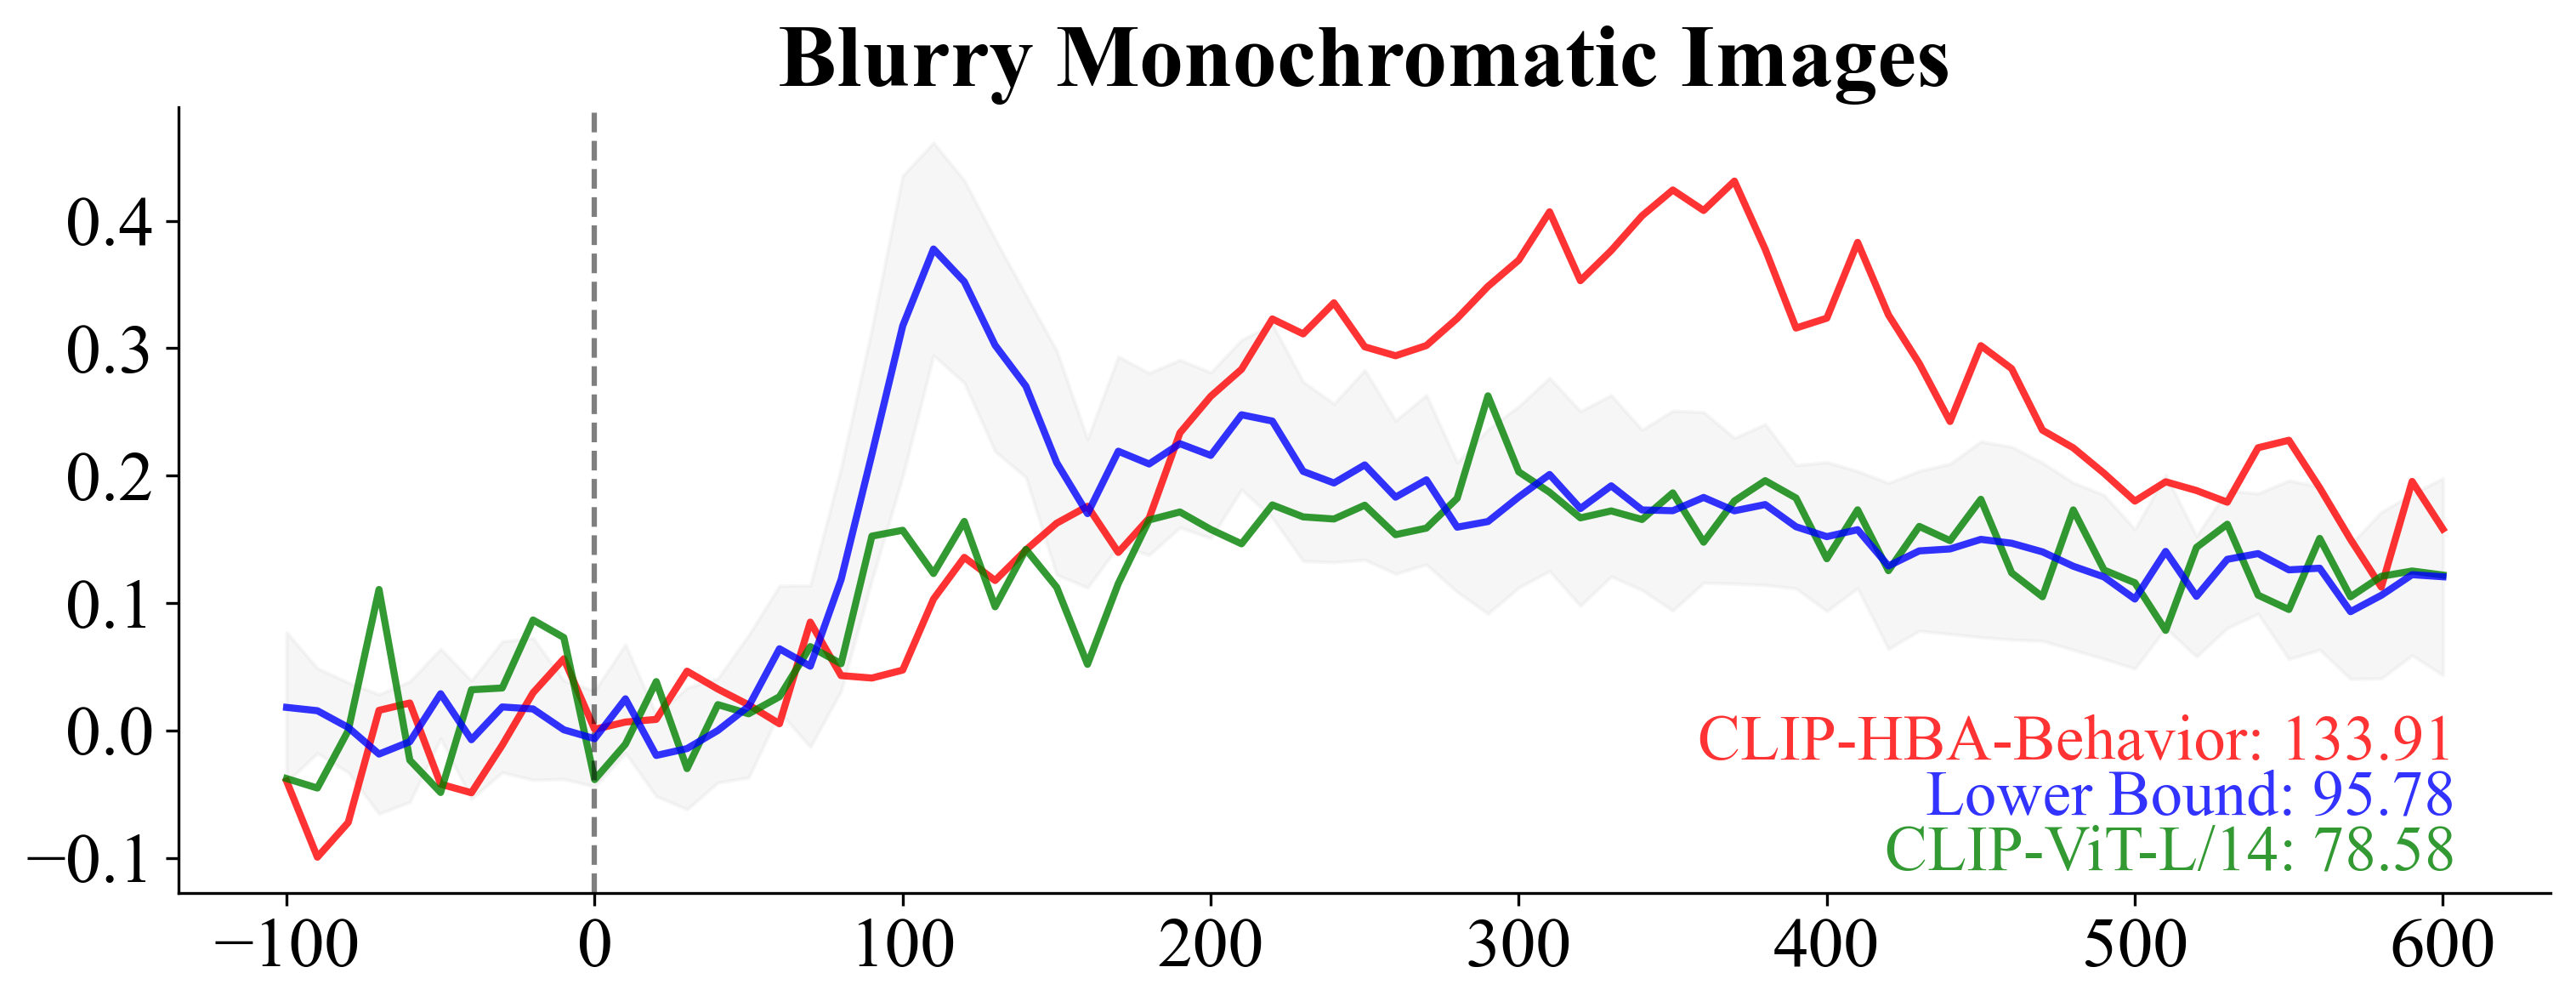

In [22]:
# Parameters
plot_title = "Blurry Monochromatic Images"
ann_x = 0.96
ann_y = 0.17
ann_delta_y = 0.07
title_fontsize = 25
text_fontsize = 18
tick_size = 20


# Plotting
fig, ax = plt.subplots(figsize=(12, 4), dpi=300)  # Set resolution
fig.patch.set_facecolor('none')  # Remove figure background
ax.set_facecolor('none')  # Remove axes background
plt.rcParams['font.family'] = 'Times New Roman'  # Set font to Times New Roman
plt.plot(neural_timepoints_list, hba_static_correlation, label='CLIP-HBA Static Correlation', color='red', linewidth=2, alpha=0.8)
plt.plot(neural_timepoints_list, baseline_static_correlation, label='Baseline Correlation', color='green', linewidth=2, alpha=0.8)
# plot straight line at auc cutoff
plt.axvline(x=auc_cutoff_ms, color='black', linestyle='--', label='AUC Cutoff', alpha=0.5)


# Plot Lower Bound with Shaded Area for ±1 STD
plt.plot(neural_timepoints_list, mean_lower_bound, label='Lower Bound', color='blue', linewidth=2, alpha=0.8)
plt.fill_between(neural_timepoints_list, mean_lower_bound - std_lower_bound, mean_lower_bound + std_lower_bound, color='lightgrey', alpha=0.2)

# Display Sorted AUC 
auc_array_dict = {'CLIP-HBA-Behavior': [auc_hba_static, "red"], 'CLIP-ViT-L/14': [auc_baseline_static, "green"], 'Lower Bound': [auc_lower_bound, "blue"]}
auc_array_dict_sorted = {k: v for k, v in sorted(auc_array_dict.items(), key=lambda item: item[1], reverse=True)}


for i in range(len(auc_array_dict_sorted)):
    plt.text(ann_x, ann_y, f"{list(auc_array_dict_sorted.keys())[i]}: {list(auc_array_dict_sorted.values())[i][0]:.2f}", color=list(auc_array_dict_sorted.values())[i][1], fontsize=text_fontsize, transform=plt.gca().transAxes, horizontalalignment='right', alpha=0.8)   
    ann_y -= ann_delta_y


# Remove top and right frame
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.xlabel('Time (ms)', fontsize=15)
# plt.ylabel("Spearman Correlation", fontsize=15)
plt.title(plot_title, fontsize=title_fontsize, fontweight='bold')
plt.xticks(fontsize=tick_size)
plt.yticks(fontsize=tick_size)
# plt.show()

plt.savefig('../figures/ds2_alignment_behavioral.svg', format='svg', transparent=True)


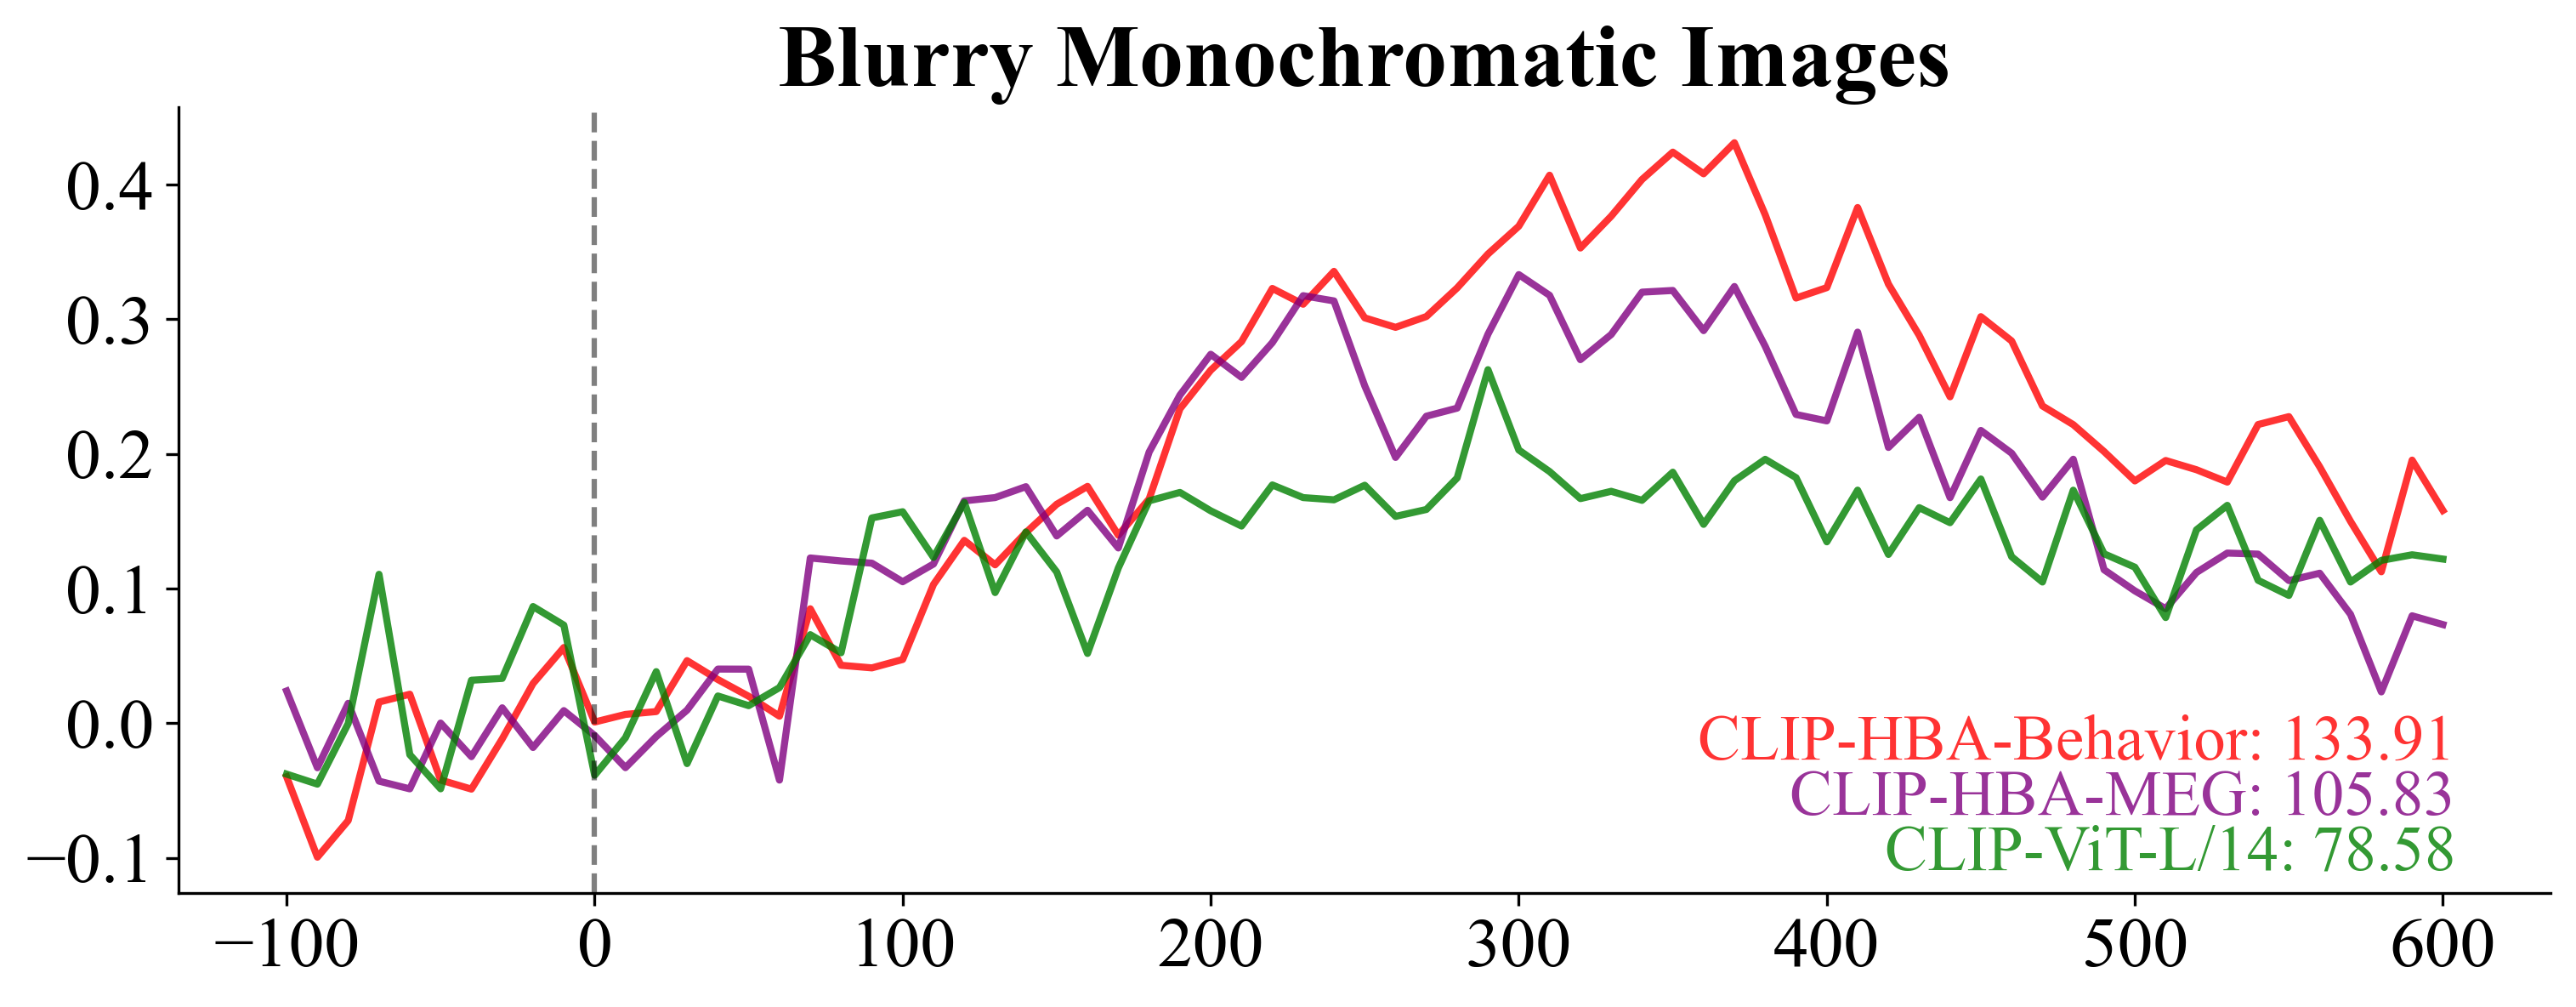

In [23]:
ann_x = 0.96
ann_y = 0.17
ann_delta_y = 0.07
title_fontsize = 25
text_fontsize = 18
tick_size = 20


# Plotting
fig, ax = plt.subplots(figsize=(12, 4), dpi=300)  # Set resolution
fig.patch.set_facecolor('none')  # Remove figure background
ax.set_facecolor('none')  # Remove axes background
plt.rcParams['font.family'] = 'Times New Roman'  # Set font to Times New Roman
plt.plot(neural_timepoints_list, hba_static_correlation, label='CLIP-HBA-Static Correlation', color='red', linewidth=2, alpha=0.8)
plt.plot(neural_timepoints_list, hba_dynamic_correlations, label='CLIP-HBA-Dynamic Correlation', color='purple', linewidth=2, alpha=0.8)
plt.plot(neural_timepoints_list, baseline_static_correlation, label='Baseline Correlation', color='green', linewidth=2, alpha=0.8)
# plot straight line at auc cutoff
plt.axvline(x=auc_cutoff_ms, color='black', linestyle='--', label='AUC Cutoff', alpha=0.5)


# Plot Lower Bound with Shaded Area for ±1 STD
# plt.plot(neural_timepoints_list, mean_lower_bound, label='Lower Bound', color='blue', linewidth=2, alpha=0.8)
# plt.fill_between(neural_timepoints_list, mean_lower_bound - std_lower_bound, mean_lower_bound + std_lower_bound, color='lightgrey', alpha=0.2)

# Display Sorted AUC 
auc_array_dict = {'CLIP-HBA-Behavior': [auc_hba_static, "red"], 'CLIP-ViT-L/14': [auc_baseline_static, "green"], 'CLIP-HBA-MEG': [auc_hba_dynamic, "purple"]}
auc_array_dict_sorted = {k: v for k, v in sorted(auc_array_dict.items(), key=lambda item: item[1], reverse=True)}


for i in range(len(auc_array_dict_sorted)):
    plt.text(ann_x, ann_y, f"{list(auc_array_dict_sorted.keys())[i]}: {list(auc_array_dict_sorted.values())[i][0]:.2f}", color=list(auc_array_dict_sorted.values())[i][1], fontsize=text_fontsize, transform=plt.gca().transAxes, horizontalalignment='right', alpha=0.8)   
    ann_y -= ann_delta_y


# Remove top and right frame
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.xlabel('Time (ms)', fontsize=15)
# plt.ylabel("Spearman Correlation", fontsize=15)
plt.title(plot_title, fontsize=title_fontsize, fontweight='bold')
plt.xticks(fontsize=tick_size)
plt.yticks(fontsize=tick_size)
# plt.show()

plt.savefig('../figures/ds2_alignment_neural.svg', format='svg', transparent=True)


# test

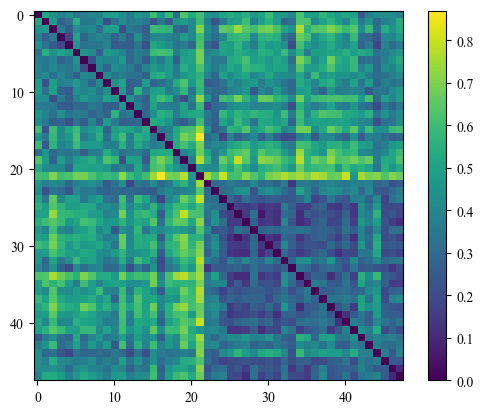

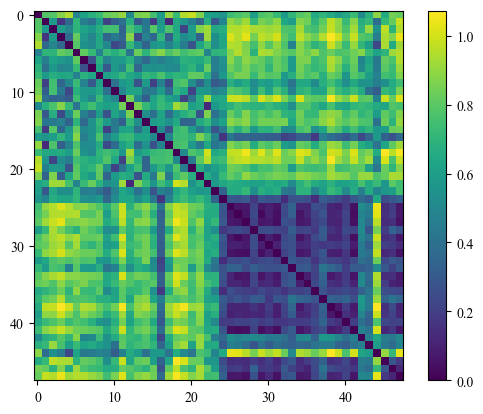

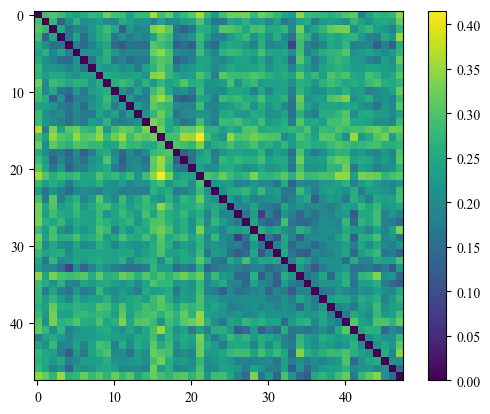

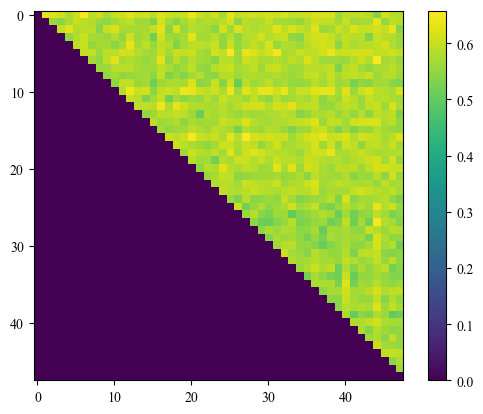

In [24]:
plt.imshow(hba_dynamic_rdms[50])
plt.colorbar()
plt.show()

plt.imshow(hba_rdm)
plt.colorbar()
plt.show()

plt.imshow(baseline_rdm)
plt.colorbar()
plt.show()

plt.imshow(average_neural_rdms[50])
plt.colorbar()
plt.show()